## 1. Derivation of the world equilibrium

We have two countries $i\in\{H,F\}$, two goods $g\in\{M,A\}$, and for each country:

- **Endowments:**  
  $\bar L_i$ units of labor (mobile),  
  $\bar K_i$ units of capital (specific to manufacturing),  
  $\bar T_i$ units of land (specific to agriculture).

- **Technologies:**
  $
    Y_{i,M} = Z_{i,M}\,K_i^{\beta_i}\,L_{i,M}^{1-\beta_i}, 
    \quad
    Y_{i,A} = Z_{i,A}\,T_i^{\beta_i}\,L_{i,A}^{1-\beta_i},
    \quad \beta_i\in(0,1).
  $

- **Labor–price FOCs (zero profits):**  
  $
    P_M(1-\beta_i)Z_{i,M}
      \Bigl(\tfrac{K_i}{L_{i,M}}\Bigr)^{\beta_i}
      = w_i,
    \quad
    P_A(1-\beta_i)Z_{i,A}
      \Bigl(\tfrac{T_i}{L_{i,A}}\Bigr)^{\beta_i}
      = w_i.
  $
  ⇒ at any $p\equiv P_M/P_A$,
  $
    \underbrace{\Bigl(\frac{P_MZ_{i,M}}{P_AZ_{i,A}}\Bigr)^{1/\beta_i}
      \frac{K_i}{T_i}}_{\Omega_i(p)}
    = \frac{L_{i,M}}{L_{i,A}},
    \quad
    L_{i,M}(p)=\frac{\Omega_i(p)}{1+\Omega_i(p)}\,\bar L_i,
    \quad
    L_{i,A}(p)=\bar L_i - L_{i,M}(p).
    \tag{1}
  $

- **Sectoral outputs** (as functions of $p$):
  $
    Y_{i,M}(p)
      = Z_{i,M}\,K_i^{\beta_i}\,(L_{i,M}(p))^{1-\beta_i},
    \quad
    Y_{i,A}(p)
      = Z_{i,A}\,T_i^{\beta_i}\,(L_{i,A}(p))^{1-\beta_i}.
    \tag{2}
  $

---

### 1.1 World aggregates

- **Relative supply**  
  $
    RS(p)
      = \frac{Y^W_M(p)}{Y^W_A(p)}
      = \frac{\sum_i Y_{i,M}(p)}{\sum_i Y_{i,A}(p)}.
    \tag{3}
  $

- **Relative demand**  
  Total income in country $i$ is
  $\,I_i(p)=P_MY_{i,M}(p)+P_AY_{i,A}(p)$.  Cobb–Douglas shares give
  $Q_{i,M}=(1-\alpha_i)I_i/P_M,\;Q_{i,A}=\alpha_iI_i/P_A$.  Hence
  $
    RD(p)
      = \frac{\sum_i Q_{i,M}(p)}{\sum_i Q_{i,A}(p)}
      = \frac{\sum_i(1-\alpha_i)I_i(p)/P_M}
             {\sum_i \alpha_iI_i(p)/P_A}
      = \frac{\sum_i(1-\alpha_i)I_i(p)}
             {\sum_i \alpha_iI_i(p)}\;\frac1p.
    \tag{4}
  $

- **Market‐clearing**  
  $
    RS(p^*) = RD(p^*)
    \quad\Longrightarrow\quad
    F(p)\equiv RS(p)-RD(p)=0,
  $
  which has a unique solution $p^*=P_M/P_A$.


## 2. Python implementation

Below is a step-by-step mapping from the derivation into code.  Students
can paste this into a Jupyter cell, tweak the primitives, and see how
each formula is implemented.


In [3]:
# =====================================================
#  WORLD EQUILIBRIUM IN THE SPECIFIC-FACTORS MODEL
# =====================================================

# 1. PRIMITIVES
Z_M = {'H':1.0, 'F':0.8}      # TFP in manufacturing
Z_A = {'H':1.0, 'F':0.6}      # TFP in agriculture
K   = {'H':4.0, 'F':2.0}      # capital endowments
T   = {'H':3.0, 'F':1.0}      # land endowments
L   = {'H':5.0, 'F':5.0}      # labor endowments
beta= {'H':0.40,'F':0.40}     # Cobb–Douglas share β_i
alpha={'H':0.50,'F':0.50}     # consumption share α_i

# 2. DOMESTIC labor split Ω_i(p)  -- implements eqn (1)
def Omega(i, p):
    return (p * Z_M[i]/Z_A[i])**(1.0/beta[i]) * (K[i]/T[i])

def Lm(i, p):
    ω = Omega(i, p)
    return (ω/(1+ω)) * L[i]

def La(i, p):
    return L[i] - Lm(i, p)

# 3. OUTPUTS Y_{i,g}(p)  -- implements eqn (2)
def Ym(i, p):
    return Z_M[i] * K[i]**beta[i] * Lm(i,p)**(1-beta[i])

def Ya(i, p):
    return Z_A[i] * T[i]**beta[i] * La(i,p)**(1-beta[i])

# 4. WORLD Relative Supply RS(p)  -- eqn (3)
def RS(p):
    num = sum(Ym(i,p) for i in ['H','F'])
    den = sum(Ya(i,p) for i in ['H','F'])
    return num/den

# 5. WORLD Relative Demand RD(p)  -- eqn (4)
def RD(p):
    # income I_i = P_M Y_M + P_A Y_A = p*Y_M + 1*Y_A
    I = {i: p*Ym(i,p) + Ya(i,p) for i in ['H','F']}
    num = sum((1-alpha[i])*I[i]/p for i in ['H','F'])
    den = sum(alpha[i]*I[i]   for i in ['H','F'])
    return num/den

# 6. EXCESS DEMAND
def excess_demand(p):
    return RS(p) - RD(p)

# 7. BISECTION 
def bisect_root(f, a, b, tol=1e-6, max_iter=100):
    fa, fb = f(a), f(b)
    if fa*fb > 0:
        raise ValueError("Root not bracketed")
    for _ in range(max_iter):
        m = 0.5*(a+b)
        fm = f(m)
        if abs(fm)<tol or (b-a)<tol:
            return m
        if fa*fm<0:
            b, fb = m, fm
        else:
            a, fa = m, fm
    raise RuntimeError("No convergence")

# 8. AUTOMATIC BRACKETING & SOLVE
p_low, p_high = 2, 2
while excess_demand(p_low) > 0:
    p_low *= 0.1
while excess_demand(p_high) < 0:
    p_high *= 10

p_star = bisect_root(excess_demand, p_low, p_high)
print("Equilibrium P_M/P_A =", p_star)

Equilibrium P_M/P_A = 0.7707118511199951


Run the notebook with baseline parameters. Record in specific variables:
$$
p^*,\quad w_H,w_F,\quad Y_{i,M},Y_{i,A},\quad L_{i,M},L_{i,A}, 
$$

In [5]:
# --- Baseline results ---
def wage(i, p):  # w_i = P_M(1-β)Z_M (K/Lm)^β
    return p*(1-beta[i])*Z_M[i]*(K[i]/Lm(i,p))**beta[i]

for i in ['H','F']:
    print(f"\nCountry {i}:")
    print(f"  w_i = {wage(i,p_star):.4f}")
    print(f"  Y_M = {Ym(i,p_star):.4f},  Y_A = {Ya(i,p_star):.4f}")
    print(f"  L_M = {Lm(i,p_star):.4f},  L_A = {La(i,p_star):.4f}")
    
# Store baseline results for later comparison
baseline = {
    'p': p_star,
    'w': {i: wage(i,p_star) for i in ['H','F']},
    'Ym': {i: Ym(i,p_star) for i in ['H','F']},
    'Ya': {i: Ya(i,p_star) for i in ['H','F']},
    'L_M':{i: Lm(i,p_star) for i in ['H','F']},
    'L_A':{i: La(i,p_star) for i in ['H','F']},    
}

baseline


Country H:
  w_i = 0.6041
  Y_M = 2.6789,  Y_A = 2.9695
  L_M = 2.0507,  L_A = 2.9493

Country F:
  w_i = 0.2989
  Y_M = 2.2030,  Y_A = 0.7930
  L_M = 3.4081,  L_A = 1.5919


{'p': 0.7707118511199951,
 'w': {'H': 0.6041013657283512, 'F': 0.298909018636971},
 'Ym': {'H': 2.678922786102496, 'F': 2.2029841187302126},
 'Ya': {'H': 2.9695005082516706, 'F': 0.7930425205069115},
 'L_M': {'H': 2.050660028217538, 'F': 3.4081259425563086},
 'L_A': {'H': 2.949339971782462, 'F': 1.5918740574436914}}

Increase manufacturing productivity by 20\% in both countries:
$$
Z'_{i,M}=1.2\,Z_{i,M}.
$$

In [7]:
# =====================================================
#  20% Productivity increase in manufacturing
# =====================================================
print(Z_M)
for x in Z_M:
    Z_M[x] = 1.2 * Z_M[x]
print(Z_M)

{'H': 1.0, 'F': 0.8}
{'H': 1.2, 'F': 0.96}


Recompute $p^*$, the wage rates, labor allocations, and outputs. Record them in new variables that will allow you to compare the baseline and new equilibria. Compare $L_{i,M}, L_{i,A}$ before and after the shock. You do not need to plot charts. Is this consistent with what we saw in class?

In [9]:

p_low, p_high = 2, 2
while excess_demand(p_low) > 0: p_low *= 0.1
while excess_demand(p_high) < 0: p_high *= 10
p_star_new = bisect_root(excess_demand, p_low, p_high)

print(f"\nAfter +20% productivity: p* = {p_star_new:.4f}")

# Store new results for later comparison
new_eq = {
    'p': p_star_new,
    'w': {i: wage(i,p_star_new) for i in ['H','F']},
    'Ym': {i: Ym(i,p_star_new) for i in ['H','F']},
    'Ya': {i: Ya(i,p_star_new) for i in ['H','F']},
    'L_M':{i: Lm(i,p_star_new) for i in ['H','F']},
    'L_A':{i: La(i,p_star_new) for i in ['H','F']},    
}


for i in ['H','F']:
    print(f"\nCountry {i}:")
    print(f"  L_M: {baseline['L_M'][i]:.4f} → {new_eq['L_M'][i]:.4f}")
    print(f"  L_A: {baseline['L_A'][i]:.4f} → {new_eq['L_A'][i]:.4f}")


After +20% productivity: p* = 0.6423

Country H:
  L_M: 2.0507 → 2.0507
  L_A: 2.9493 → 2.9493

Country F:
  L_M: 3.4081 → 3.4081
  L_A: 1.5919 → 1.5919


Labor market allocations do not change! This might be surprising. Recall that labor market allocations are pinned down by $\omega$, that depend on:

$$ \underbrace{\Bigl(p \frac{ Z_{i,M}}{ Z_{i,A}}\Bigr)^{1/\beta_i} \frac{K_i}{T_i}}_{\Omega_i(p)} = \frac{L_{i,M}}{L_{i,A}}$$

But it is explained by the fact that prices will also change exactly in the way to offset the increase in productivity, so:

$$ p'/p = Z_{i,M}/Z'_{i,M} $$



In [26]:
print(f"change in prices: {p_star_new/p_star}")
print(f"(inverse of) change in Z_M: {1./1.2}")

change in prices: 0.8333332199055389
(inverse of) change in Z_M: 0.8333333333333334


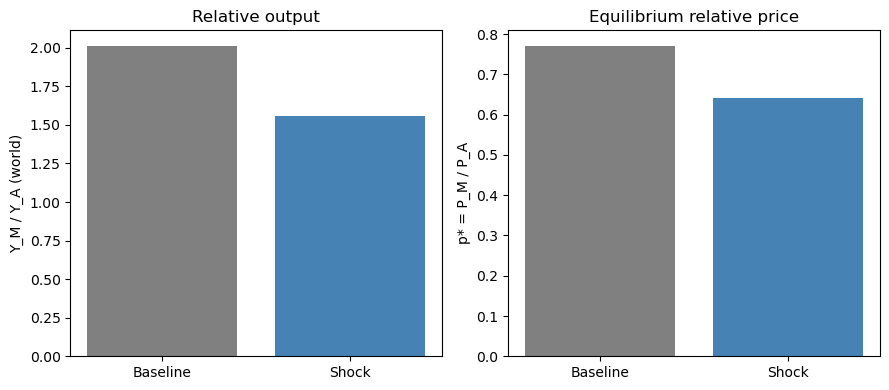

In [12]:
import matplotlib.pyplot as plt

rel_out_base = RS(p_star)
rel_out_new  = RS(p_star_new)

plt.figure(figsize=(9,4))
plt.subplot(1,2,1)
plt.bar(['Baseline','Shock'], [rel_out_base, rel_out_new], color=['gray','steelblue'])
plt.ylabel('Y_M / Y_A (world)')
plt.title('Relative output')

plt.subplot(1,2,2)
plt.bar(['Baseline','Shock'], [p_star, p_star_new], color=['gray','steelblue'])
plt.ylabel('p* = P_M / P_A')
plt.title('Equilibrium relative price')
plt.tight_layout()
plt.show()

In [13]:

print("\nReal wage comparison:")
for i in ['H','F']:
    w0 = baseline['w'][i]
    wn = new_eq['w'][i]
    print(f"{i}:  w/P_M  {w0/p_star:.4f} → {wn/p_star_new:.4f}   "
          f"|  w/P_A  {w0/1.0:.4f} → {wn/1.0:.4f}")


Real wage comparison:
H:  w/P_M  0.7838 → 0.9406   |  w/P_A  0.6041 → 0.6041
F:  w/P_M  0.3878 → 0.4654   |  w/P_A  0.2989 → 0.2989
